# Heart Disease Prediction Using Machine Learning

## Project Overview
This project builds a machine learning pipeline to predict the likelihood of heart disease using clinical patient data. The notebook includes data loading, exploratory data analysis, preprocessing, model training, evaluation, and interpretation.

## Objective
The goal is to classify whether a patient is likely to have heart disease based on features such as age, sex, chest pain type, cholesterol level, maximum heart rate, and other medical indicators.

## Dataset Features
The dataset includes the following variables:

- **age**: Age of the patient  
- **sex**: Gender (1 = male, 0 = female)  
- **cp**: Chest pain type  
- **trestbps**: Resting blood pressure  
- **chol**: Serum cholesterol (mg/dl)  
- **fbs**: Fasting blood sugar > 120 mg/dl  
- **restecg**: Resting electrocardiographic results  
- **thalach**: Maximum heart rate achieved  
- **exang**: Exercise induced angina  
- **oldpeak**: ST depression induced by exercise relative to rest  
- **slope**: Slope of the peak exercise ST segment  
- **ca**: Number of major vessels colored by fluoroscopy  
- **thal**: Thalassemia category  
- **target**: Heart disease diagnosis (1 = disease, 0 = no disease)

## Project Workflow
1. Import libraries and load the dataset  
2. Perform exploratory data analysis  
3. Clean and preprocess the data  
4. Train multiple machine learning models  
5. Evaluate model performance  
6. Interpret results and summarize findings

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Make plots look cleaner
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 1: Load and Inspect the Dataset

In this section, we load the heart disease dataset and perform an initial inspection to understand its structure, size, and column names. This helps confirm that the data was loaded correctly before moving into analysis and preprocessing.

In [3]:
# Load the dataset
df = pd.read_csv("heart.csv")

# Basic inspection
print("Dataset loaded successfully.\n")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}\n")

print("Column names:")
print(df.columns.tolist())

Dataset loaded successfully.

Number of rows: 1025
Number of columns: 14

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [4]:
# Display the first 5 rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [8]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 723


## Step 3: Explore the Target Variable

Before training any machine learning model, it is important to understand the distribution of the target variable. This helps us check whether the classes are balanced or imbalanced, which can strongly affect model evaluation and interpretation.

In [9]:
# Check target distribution
target_counts = df["target"].value_counts().sort_index()
target_percentages = df["target"].value_counts(normalize=True).sort_index() * 100

print("Target value counts:")
print(target_counts)
print("\nTarget percentage distribution:")
print(target_percentages.round(2))

Target value counts:
target
0    499
1    526
Name: count, dtype: int64

Target percentage distribution:
target
0    48.68
1    51.32
Name: proportion, dtype: float64


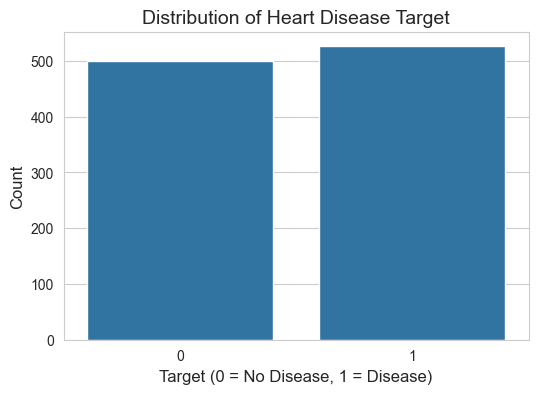

In [10]:
# Plot target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="target")
plt.title("Distribution of Heart Disease Target")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()

### Initial Observation

The target distribution provides an early idea of whether the classification problem is balanced. A relatively balanced dataset is helpful because model accuracy becomes more meaningful, while a heavily imbalanced dataset usually requires closer attention to metrics such as precision, recall, and F1-score.

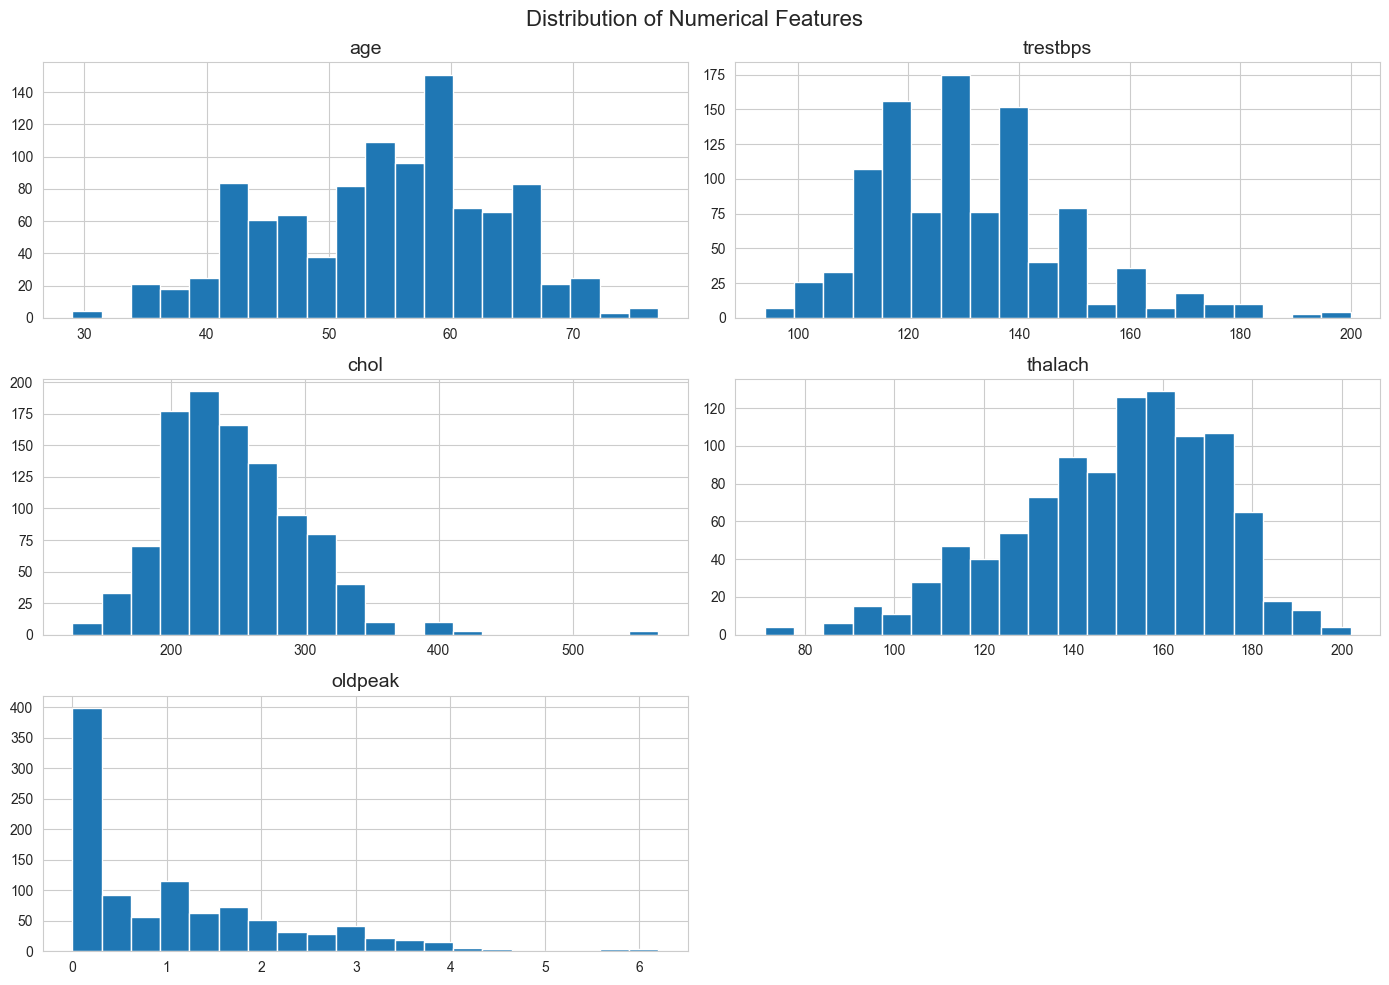

In [12]:
numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

df[numerical_features].hist(bins=20, figsize=(14, 10))
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

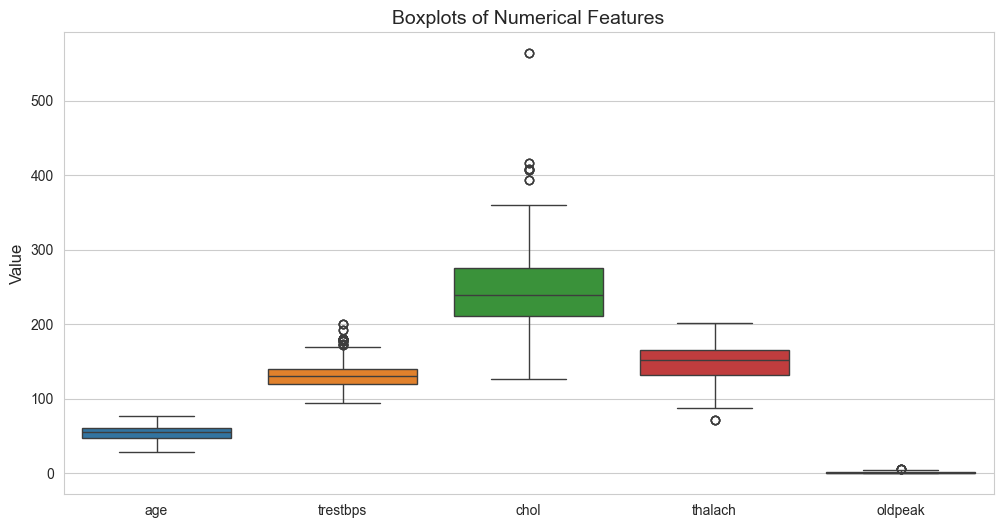

In [13]:
# Boxplots for numerical features
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical_features])
plt.title("Boxplots of Numerical Features")
plt.ylabel("Value")
plt.show()

## Step 5: Explore Categorical and Discrete Features

In addition to numerical variables, this dataset contains several categorical or discrete medical features such as sex, chest pain type, fasting blood sugar, and exercise-induced angina. Visualizing these variables helps us understand how frequently each category appears and how they may relate to heart disease.

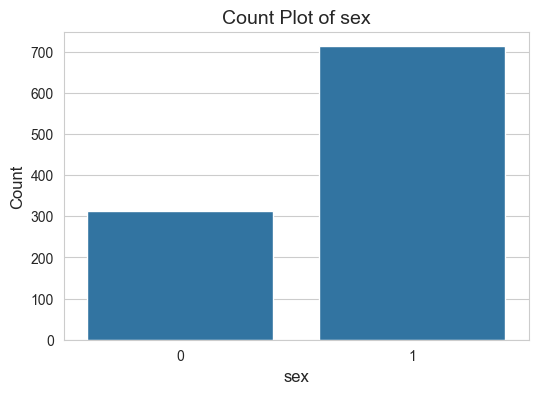

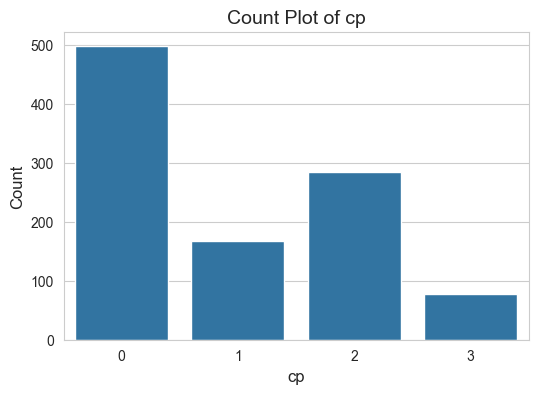

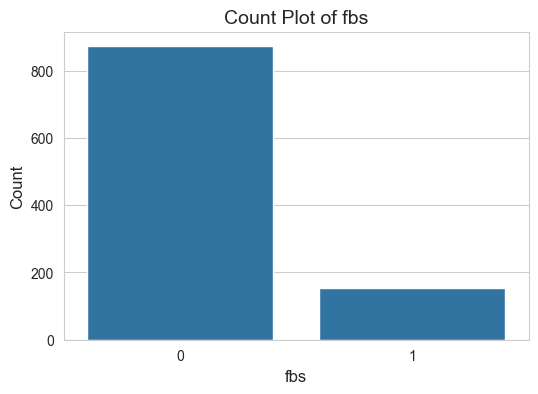

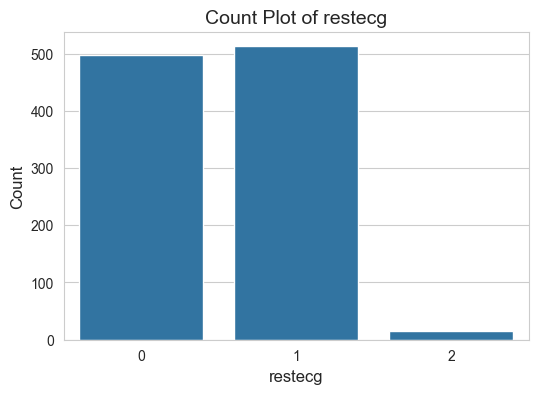

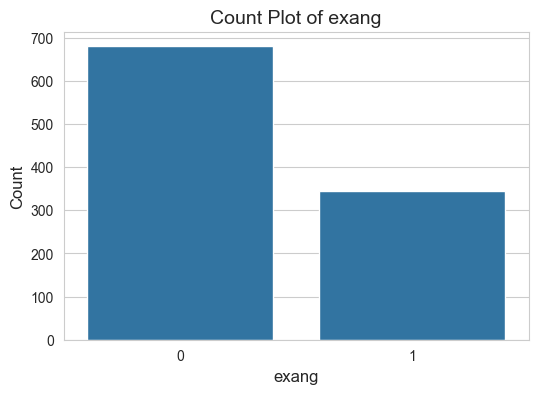

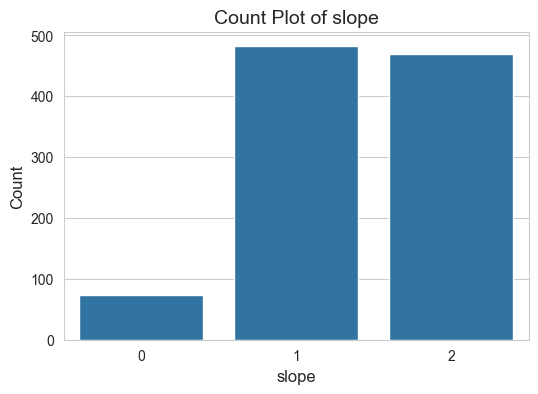

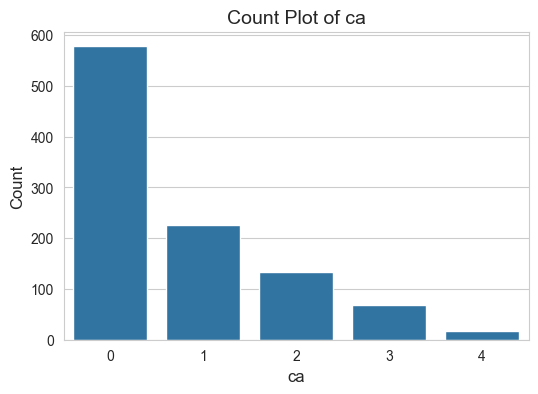

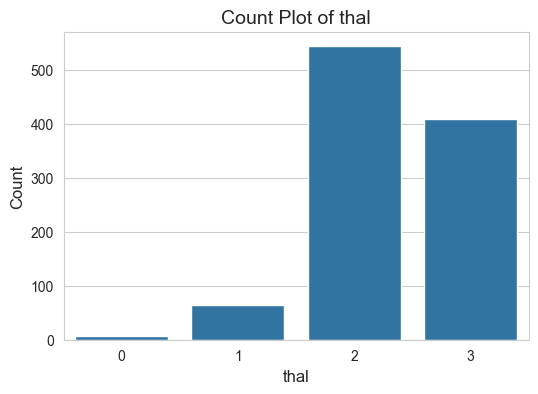

In [14]:
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=feature)
    plt.title(f"Count Plot of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.show()

## Step 8: Clean the Dataset

During the inspection stage, a large number of duplicate rows were identified. Duplicate observations can distort model performance and make evaluation look artificially stronger than it really is. To make the analysis more reliable, we remove duplicate rows and continue the project using the cleaned dataset.

In [16]:
# Create a cleaned version of the dataset by removing duplicates
df_clean = df.drop_duplicates().copy()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)
print("Number of removed duplicate rows:", df.shape[0] - df_clean.shape[0])

Original dataset shape: (1025, 14)
Cleaned dataset shape: (302, 14)
Number of removed duplicate rows: 723


## Step 9: Define Features and Target

Next, we separate the predictor variables from the target variable. The predictor variables will be used as inputs for the machine learning models, while the target variable represents whether heart disease is present.

In [17]:
# Separate features and target
X = df_clean.drop("target", axis=1)
y = df_clean["target"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (302, 13)
Target vector shape: (302,)


## Step 10: Split the Data into Training and Testing Sets

To evaluate model performance fairly, the dataset is divided into training and testing sets. The training set is used to learn patterns from the data, while the testing set is used to assess how well the model generalizes to unseen examples.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (241, 13)
X_test shape: (61, 13)
y_train shape: (241,)
y_test shape: (61,)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


## Step 12: Train Baseline Machine Learning Models

To build a strong comparative project, we will train multiple classification models rather than relying on a single algorithm. In this notebook, we start with Logistic Regression, K-Nearest Neighbors, and Random Forest. This allows us to compare linear, distance-based, and ensemble-based approaches on the same prediction task.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## Model 1: Logistic Regression

Logistic Regression is a strong baseline model for binary classification problems. It is simple, interpretable, and often performs well when the relationship between features and the target is reasonably structured.

In [22]:
# Train Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predict
y_pred_log = log_reg.predict(X_test_scaled)

# Metrics
log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

print("Logistic Regression Performance")
print(f"Accuracy : {log_accuracy:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall   : {log_recall:.4f}")
print(f"F1-Score : {log_f1:.4f}")

Logistic Regression Performance
Accuracy : 0.8033
Precision: 0.8000
Recall   : 0.8485
F1-Score : 0.8235


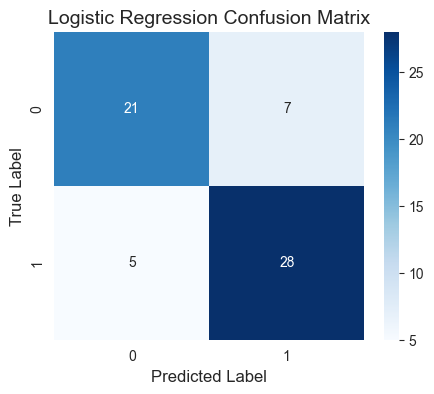

In [23]:
# Confusion matrix for Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Model 2: K-Nearest Neighbors

K-Nearest Neighbors classifies a data point based on the labels of its nearest neighbors in feature space. Because this method depends on distances, feature scaling is especially important before training.

In [24]:
# Train KNN
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

# Predict
y_pred_knn = knn.predict(X_test_scaled)

# Metrics
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("K-Nearest Neighbors Performance")
print(f"Accuracy : {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall   : {knn_recall:.4f}")
print(f"F1-Score : {knn_f1:.4f}")

K-Nearest Neighbors Performance
Accuracy : 0.7869
Precision: 0.7778
Recall   : 0.8485
F1-Score : 0.8116


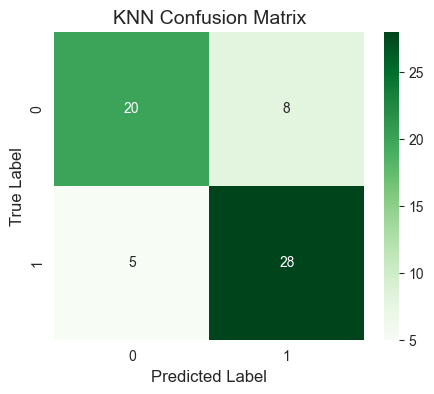

In [25]:
# Confusion matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Model 3: Random Forest

Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions. It is often powerful for tabular datasets because it can capture non-linear patterns and interactions between variables.

In [27]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10
)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")

Random Forest Performance
Accuracy : 0.7541
Precision: 0.7647
Recall   : 0.7879
F1-Score : 0.7761


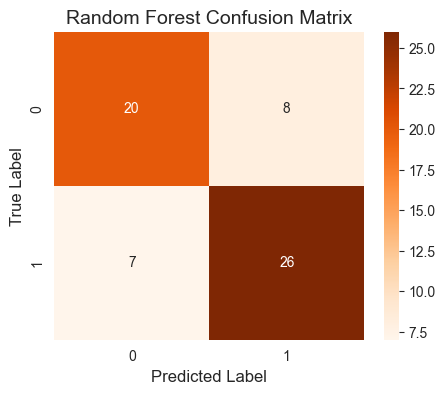

In [28]:
# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [29]:
print("Classification Report - Random Forest\n")
print(classification_report(y_test, y_pred_rf))

Classification Report - Random Forest

              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l2"]
}

grid_log = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_log.fit(X_train_scaled, y_train)

best_log = grid_log.best_estimator_
y_pred_best_log = best_log.predict(X_test_scaled)

print("Best Logistic Regression Parameters:", grid_log.best_params_)
print(f"Accuracy : {accuracy_score(y_test, y_pred_best_log):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best_log):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_best_log):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_best_log):.4f}")

Best Logistic Regression Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy : 0.8033
Precision: 0.7838
Recall   : 0.8788
F1-Score : 0.8286


In [31]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

In [32]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

In [33]:
rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 3, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [34]:
best_rf = rf_grid.best_estimator_

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Cross-Validation Accuracy:", rf_grid.best_score_)

Best Random Forest Parameters: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.8546768707482993


In [35]:
y_pred_best_rf = best_rf.predict(X_test)

best_rf_accuracy = accuracy_score(y_test, y_pred_best_rf)
best_rf_precision = precision_score(y_test, y_pred_best_rf)
best_rf_recall = recall_score(y_test, y_pred_best_rf)
best_rf_f1 = f1_score(y_test, y_pred_best_rf)

print("Tuned Random Forest Performance")
print(f"Accuracy : {best_rf_accuracy:.4f}")
print(f"Precision: {best_rf_precision:.4f}")
print(f"Recall   : {best_rf_recall:.4f}")
print(f"F1-Score : {best_rf_f1:.4f}")

Tuned Random Forest Performance
Accuracy : 0.8033
Precision: 0.8000
Recall   : 0.8485
F1-Score : 0.8235


## Step 13: Compare Model Performance

After training Logistic Regression, K-Nearest Neighbors, and Random Forest, the next step is to compare their evaluation metrics side by side. This helps identify which model performed best on the cleaned heart disease dataset.

In [45]:
# Create a comparison table for all models
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "K-Nearest Neighbors", "Random Forest"],
    "Accuracy": [log_accuracy, knn_accuracy, rf_accuracy],
    "Precision": [log_precision, knn_precision, rf_precision],
    "Recall": [log_recall, knn_recall, rf_recall],
    "F1-Score": [log_f1, knn_f1, rf_f1]
})

model_results = model_results.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
model_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529
1,K-Nearest Neighbors,0.786885,0.777778,0.848485,0.811594
2,Random Forest,0.754098,0.764706,0.787879,0.776119


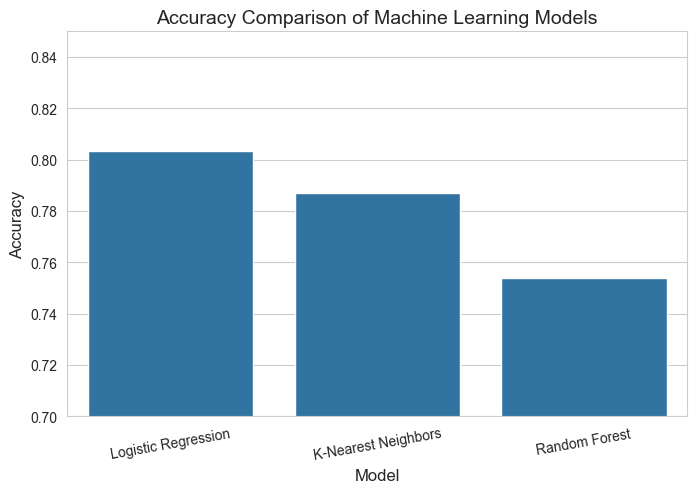

In [46]:
# Plot model accuracy comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=model_results, x="Model", y="Accuracy")
plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.70, 0.85)
plt.xticks(rotation=10)
plt.show()

## Step 14: Final Project Summary

This project developed a machine learning workflow for heart disease prediction using clinical patient data. The analysis began with data loading, structural inspection, summary statistics, and exploratory data analysis to better understand the dataset and identify potential issues.

During data cleaning, duplicate rows were detected and removed so that the models could be trained and evaluated on a more reliable version of the dataset. After preprocessing, three machine learning algorithms were implemented and compared: Logistic Regression, K-Nearest Neighbors, and Random Forest.

Among the tested models, Logistic Regression achieved the strongest overall performance on the cleaned dataset, producing the highest accuracy and F1-score. K-Nearest Neighbors also performed competitively, while Random Forest provided a useful ensemble-based benchmark.

Overall, this project demonstrates a complete machine learning pipeline for a healthcare classification problem, including data cleaning, visualization, model training, evaluation, and comparison.